<a href="https://colab.research.google.com/github/viktoruebelhart/pos_facens/blob/main/Penguins_AprendizadoSupervisionado_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aprendizado Supervisionado — Classificação com o *Palmer Penguins*

---

Este notebook documenta, **passo a passo**, a construção de um modelo de **classificação supervisionada**, explicando as decisões em cada etapa: a escolha do dataset, o entendimento dos dados (o que são, unidade de medida e ordem de grandeza), a razão da padronização, a separação treino/teste (*split*), a criação do modelo e a sua validação.

**Problema:** dadas algumas medidas corporais de um pinguim, prever a qual **espécie** ele pertence (*Adelie*, *Gentoo* ou *Chinstrap*).

Por se tratar de uma tarefa em que conhecemos a resposta correta (a espécie) para cada exemplo durante o treino, estamos no paradigma de **aprendizado supervisionado** — mais especificamente, **classificação** (a saída é uma categoria, não um número contínuo).

## 1. Escolha do dataset

Escolhi o **Palmer Penguins**, um conjunto de dados coletado na *Palmer Station*, na Antártica, com medições de três espécies de pinguins.

Pontos exigidos nesta tarefa:

- **É um problema de classificação supervisionada real**, com 3 classes bem definidas.
- **As features estão em unidades e ordens de grandeza bem diferentes** (milímetros vs. gramas).
- **Possui alguns valores ausentes (NaN)**

Carregamos o dataset diretamente de uma URL pública (formato CSV).

In [ ]:
# Bibliotecas usadas ao longo do notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (7, 4)

# Carregando o dataset Palmer Penguins a partir de uma URL pública
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
df = pd.read_csv(url)

print("Formato (linhas, colunas):", df.shape)
df.head()

Formato (linhas, colunas): (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


## 2. O que são os dados? Unidade de medida e ordem de grandeza

Cada **linha** é um pinguim observado. As **colunas** se dividem em:

**Variável-alvo (*target* — o que queremos prever):**
- `species` — a espécie do pinguim. É **categórica** e assume 3 valores: *Adelie*, *Gentoo*, *Chinstrap*.

**Variáveis preditoras (*features*):**

| Feature | O que mede | Unidade de medida | Ordem de grandeza típica |
|---|---|---|---|
| `bill_length_mm` | comprimento do bico | milímetros (mm) | dezenas (~33 a 60) |
| `bill_depth_mm` | profundidade/altura do bico | milímetros (mm) | dezenas (~13 a 22) |
| `flipper_length_mm` | comprimento da nadadeira | milímetros (mm) | centenas (~172 a 231) |
| `body_mass_g` | massa corporal | **gramas (g)** | **milhares (~2700 a 6300)** |
| `island` | ilha onde foi observado | categórica | — |
| `sex` | sexo | categórica | — |

Observe o ponto central: três features estão em **milímetros** e uma (`body_mass_g`) está em **gramas**, com valores **na casa dos milhares**.


In [ ]:
# Tipo de cada coluna (numérica vs. objeto/categórica)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [ ]:
# Distribuição da variável-alvo: quantos exemplos de cada espécie?
df['species'].value_counts()

,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


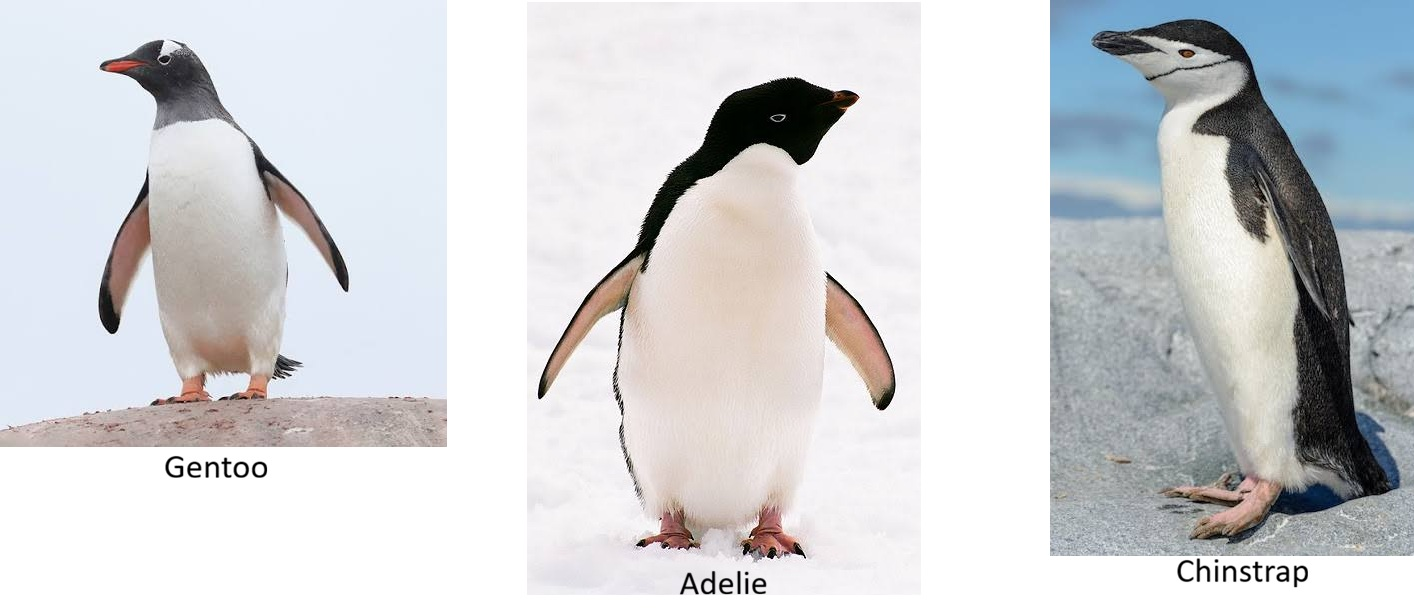

In [ ]:
# Estatísticas descritivas das features numéricas
df.describe().round(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.00,342.00,342.00,342.00
mean,43.92,17.15,200.92,4201.75
std,5.46,1.97,14.06,801.95
min,32.10,13.10,172.00,2700.00
25%,39.22,15.60,190.00,3550.00
50%,44.45,17.30,197.00,4050.00
75%,48.50,18.70,213.00,4750.00
max,59.60,21.50,231.00,6300.00


### Leitura da escala (ordem de grandeza)

Olhando a tabela acima, fica evidente o contraste de escalas:

- `body_mass_g` gira em torno de **~4200**, variando de ~2700 a ~6300.
- `bill_depth_mm` gira em torno de **~17**, variando de ~13 a ~22.

Ou seja, a massa corporal é cerca de **250 vezes maior** (em valor absoluto) que a profundidade do bico.

## 3. Limpeza dos dados (tratamento de valores ausentes)

Existem algumas linhas com valores ausentes (`NaN`).

In [ ]:
# Quantos valores ausentes existem por coluna?
df.isna().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


Como o número de linhas com ausências é pequeno frente ao total (344 linhas), a estratégia mais simples e segura aqui é **remover** essas linhas.

Vamos focar apenas nas **4 features numéricas** e na coluna-alvo.

In [ ]:
# Selecionamos as features numéricas e o alvo
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
alvo = 'species'

# Removemos linhas com ausência em qualquer dessas colunas
df_limpo = df.dropna(subset=features + [alvo]).reset_index(drop=True)

print("Antes da limpeza:", df.shape[0], "linhas")
print("Depois da limpeza:", df_limpo.shape[0], "linhas")
df_limpo[features + [alvo]].head()

Antes da limpeza: 344 linhas
Depois da limpeza: 342 linhas


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species
0,39.1,18.7,181.0,3750.0,Adelie
1,39.5,17.4,186.0,3800.0,Adelie
2,40.3,18.0,195.0,3250.0,Adelie
3,36.7,19.3,193.0,3450.0,Adelie
4,39.3,20.6,190.0,3650.0,Adelie


## 4. Análise exploratória

Antes de modelar, vale visualizar os dados para ganhar intuição: as classes são separáveis pelas medidas que temos?

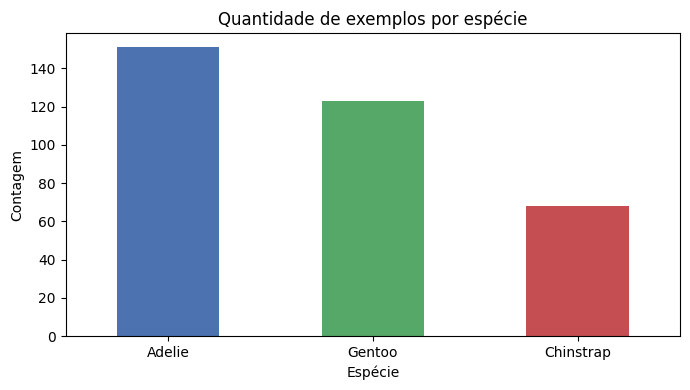

In [ ]:
# Distribuição das espécies
df_limpo['species'].value_counts().plot(kind='bar', color=['#4C72B0', '#55A868', '#C44E52'])
plt.title("Quantidade de exemplos por espécie")
plt.xlabel("Espécie"); plt.ylabel("Contagem")
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

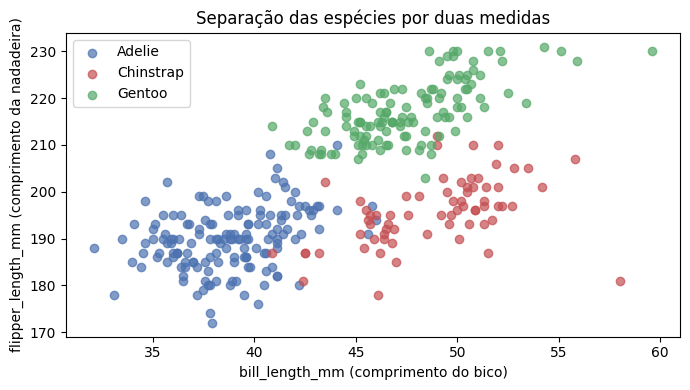

In [ ]:
# Dispersão: comprimento do bico x comprimento da nadadeira, colorido por espécie
cores = {'Adelie': '#4C72B0', 'Gentoo': '#55A868', 'Chinstrap': '#C44E52'}
for especie, grupo in df_limpo.groupby('species'):
    plt.scatter(grupo['bill_length_mm'], grupo['flipper_length_mm'],
                label=especie, alpha=0.7, color=cores[especie])
plt.xlabel("bill_length_mm (comprimento do bico)")
plt.ylabel("flipper_length_mm (comprimento da nadadeira)")
plt.title("Separação das espécies por duas medidas")
plt.legend(); plt.tight_layout(); plt.show()

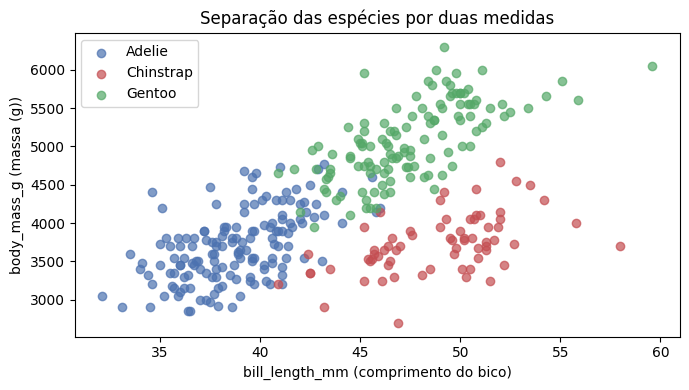

In [ ]:
# Dispersão: comprimento do bico x peso, colorido por espécie
cores = {'Adelie': '#4C72B0', 'Gentoo': '#55A868', 'Chinstrap': '#C44E52'}
for especie, grupo in df_limpo.groupby('species'):
    plt.scatter(grupo['bill_length_mm'], grupo['body_mass_g'],
                label=especie, alpha=0.7, color=cores[especie])
plt.xlabel("bill_length_mm (comprimento do bico)")
plt.ylabel("body_mass_g (massa (g))")
plt.title("Separação das espécies por duas medidas")
plt.legend(); plt.tight_layout(); plt.show()

O gráfico mostra que as espécies formam grupos razoavelmente bem separados — um bom sinal de que um modelo conseguirá aprender a distingui-las.

## 5. Por que padronizar?

Muitos algoritmos — em especial os baseados em **distância**, como o **KNN** (*k-vizinhos mais próximos*) que usaremos — calculam a proximidade entre pontos usando a **distância euclidiana**:

$$d(p, q) = \sqrt{(p_1 - q_1)^2 + (p_2 - q_2)^2 + \dots + (p_n - q_n)^2}$$

O problema: cada termo dessa soma é o **quadrado da diferença** em cada feature. Se uma feature tem valores na casa dos **milhares** (`body_mass_g`) e outra na casa das **dezenas** (`bill_depth_mm`), a diferença em massa corporal será numericamente **gigantesca** comparada às demais. Resultado: a distância passa a ser **dominada quase só pela massa corporal**, e as outras três medidas tornam-se quase irrelevantes — não porque sejam menos importantes, mas apenas porque sua **escala** é menor.

Vamos evidenciar isso comparando os **desvios-padrão** das features na escala bruta.

In [ ]:
# O desvio-padrão mede a dispersão de cada feature na sua própria escala
desvios = df_limpo[features].std().round(2)
print("Desvio-padrao de cada feature (escala bruta):")
print(desvios.to_string())

Desvio-padrao de cada feature (escala bruta):
bill_length_mm         5.46
bill_depth_mm          1.97
flipper_length_mm     14.06
body_mass_g          801.95


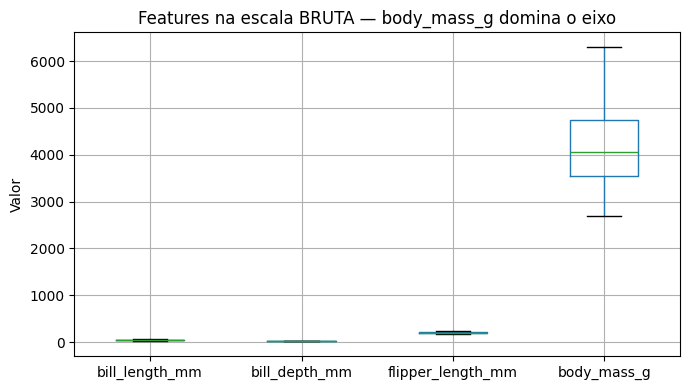

In [ ]:
# Visualizando as escalas em um único gráfico (boxplot)
# body_mass_g "achata" todas as outras por causa da sua magnitude
df_limpo[features].boxplot()
plt.title("Features na escala BRUTA — body_mass_g domina o eixo")
plt.ylabel("Valor")
plt.tight_layout(); plt.show()

O desvio-padrão de `body_mass_g` é centenas de vezes maior que o de `bill_depth_mm`. No boxplot, as três medidas em milímetros ficam praticamente "esmagadas" na base, porque a massa corporal ocupa todo o eixo.

**A padronização resolve isso.** Usaremos a *padronização Z-score* (`StandardScaler`), que transforma cada feature para ter **média 0 e desvio-padrão 1**:


Após a transformação, todas as features passam a contribuir em **pé de igualdade** para o cálculo da distância.

## 6. Separação treino/teste (*split*)

Para avaliar o modelo de forma honesta, precisamos medir seu desempenho em dados que ele **nunca viu durante o treino**. Por isso dividimos o dataset em:

- **Treino (80%)** — usado para o modelo *aprender*.
- **Teste (20%)** — usado apenas para *avaliar*, simulando dados novos.

Dois detalhes importantes:
- `random_state=42` deixa a divisão **reproduzível** (mesmo resultado a cada execução).
- `stratify=y` garante que a **proporção de cada espécie** seja mantida tanto no treino quanto no teste — essencial quando as classes são desbalanceadas (temos mais *Adelie* que *Chinstrap*).

In [ ]:
from sklearn.model_selection import train_test_split

X = df_limpo[features].values   # matriz de features
y = df_limpo[alvo].values       # vetor-alvo (espécies)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)

Treino: (273, 4) | Teste: (69, 4)


In [ ]:
# Conferindo que a estratificação preservou as proporções das classes
print("Proporção no treino:")
print(pd.Series(y_train).value_counts(normalize=True).round(3))
print("\nProporção no teste:")
print(pd.Series(y_test).value_counts(normalize=True).round(3))

Proporção no treino:
Adelie       0.443
Gentoo       0.359
Chinstrap    0.198
Name: proportion, dtype: float64

Proporção no teste:
Adelie       0.435
Gentoo       0.362
Chinstrap    0.203
Name: proportion, dtype: float64


## 7. Padronização

O `StandardScaler` aprende a média ($\mu$) e o desvio ($\sigma$) com o método `fit`. Esse `fit` deve ser feito **somente com os dados de treino**.

Por quê? Se calcularmos a média/desvio usando também o conjunto de teste, estaríamos "vazando" informação do teste para dentro do pré-processamento — o chamado **data leakage**. Isso produz uma avaliação otimista e irreal.

A receita correta é:
1. `fit` no **treino** (aprende $\mu$ e $\sigma$ só dali).
2. `transform` no **treino** e no **teste** (aplica a mesma transformação em ambos).

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)                       # aprende média e desvio APENAS do treino

X_train_scaled = scaler.transform(X_train)  # aplica no treino
X_test_scaled  = scaler.transform(X_test)   # aplica no teste com os MESMOS parâmetros

# Conferindo: no treino padronizado, média ~0 e desvio ~1 em todas as features
print("Média por feature (treino padronizado):", np.round(X_train_scaled.mean(axis=0), 2))
print("Desvio por feature (treino padronizado):", np.round(X_train_scaled.std(axis=0), 2))

Média por feature (treino padronizado): [-0.  0. -0. -0.]
Desvio por feature (treino padronizado): [1. 1. 1. 1.]


## 8. Criação do modelo e validação

Usaremos o **KNN** (`KNeighborsClassifier`), um classificador baseado em distância — justamente o tipo de modelo mais sensível à escala das features. Isso nos permite **demonstrar na prática** o efeito da padronização.

Vamos treinar **dois modelos idênticos** e comparar:
- **Modelo A:** treinado com os dados na **escala bruta** (sem padronizar).
- **Modelo B:** treinado com os dados **padronizados**.

E avaliaremos com três métricas:
- **Acurácia** — proporção total de acertos.
- **F1-score (macro)** — média do F1 por classe; trata todas as classes com peso igual (bom para classes desbalanceadas).
- **Matriz de confusão** — mostra onde o modelo erra (qual classe é confundida com qual).

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Modelo A — SEM padronização (escala bruta)
modelo_bruto = KNeighborsClassifier()
modelo_bruto.fit(X_train, y_train)
y_pred_bruto = modelo_bruto.predict(X_test)

# Modelo B — COM padronização
modelo_pad = KNeighborsClassifier()
modelo_pad.fit(X_train_scaled, y_train)
y_pred_pad = modelo_pad.predict(X_test_scaled)

In [ ]:
# Comparação das métricas
print("=== SEM padronização (escala bruta) ===")
print("Acurácia : %.3f" % accuracy_score(y_test, y_pred_bruto))
print("F1 macro : %.3f" % f1_score(y_test, y_pred_bruto, average='macro'))

print("\n=== COM padronização ===")
print("Acurácia : %.3f" % accuracy_score(y_test, y_pred_pad))
print("F1 macro : %.3f" % f1_score(y_test, y_pred_pad, average='macro'))

=== SEM padronização (escala bruta) ===
Acurácia : 0.739
F1 macro : 0.634

=== COM padronização ===
Acurácia : 1.000
F1 macro : 1.000


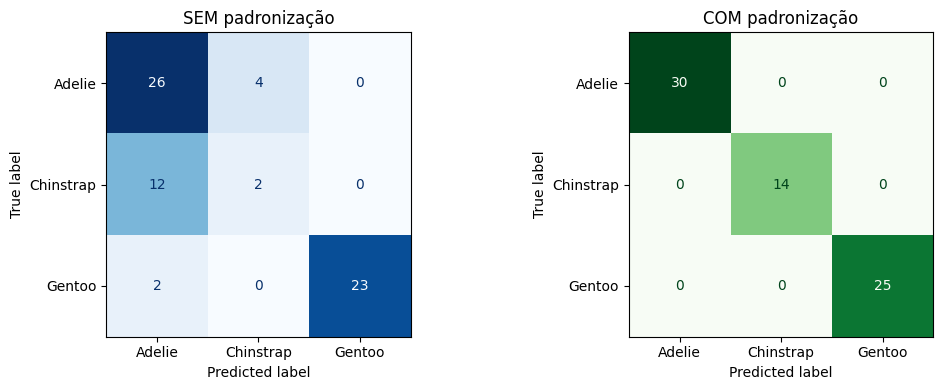

In [ ]:
# Matrizes de confusão lado a lado
classes = modelo_pad.classes_
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_bruto), display_labels=classes).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("SEM padronização")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_pad), display_labels=classes).plot(
    ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title("COM padronização")

plt.tight_layout(); plt.show()

### Interpretação dos resultados

A diferença é gritante. Sem padronização, o KNN acerta cerca de **74%** — e a matriz de confusão mostra que ele **confunde bastante *Adelie* e *Chinstrap***. Faz todo sentido: essas duas espécies têm **massa corporal parecida**, e como a distância estava dominada por `body_mass_g`, o modelo praticamente "enxergava" só o peso e ignorava as diferenças de bico, que justamente separam essas duas espécies.

Com a padronização, todas as features passam a pesar igualmente e a acurácia salta para **100%** neste conjunto de teste. As medidas do bico voltam a "ter voz" no cálculo da distância, e *Adelie* e *Chinstrap* deixam de ser confundidas.

Esta é a evidência empírica do **porquê da padronização**: ela não mudou os dados, apenas colocou as features na **mesma escala**, permitindo que o algoritmo baseado em distância usasse **toda** a informação disponível.

**Observação de rigor:** uma acurácia de 100% reflete tanto a boa separabilidade destas espécies quanto a facilidade do problema — mas é o resultado de **uma única divisão** treino/teste. Em um trabalho mais rigoroso, o próximo passo natural seria usar **validação cruzada** (*cross-validation*) e testar a sensibilidade do KNN ao hiperparâmetro `k`, para confirmar que o desempenho se mantém em diferentes partições dos dados.

## 9. Validação cruzada (cross-validation)

A **validação cruzada k-fold**: divide os dados em *k* partes (folds), treina em *k–1* e testa na parte restante, repetindo até que cada parte tenha sido o teste uma vez. No fim temos *k* notas — e olhamos a **média** e o **desvio-padrão** delas.

Dois cuidados importantes:
- Usamos `StratifiedKFold` para manter a proporção das espécies em cada fold.
- Colocamos o `StandardScaler` dentro de um `Pipeline`. Assim, em cada fold, o scaler é ajustado **só com a parte de treino daquele fold** — evitando *data leakage* durante a validação.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Pipeline: padroniza E classifica como uma coisa só.
# Dentro da CV, o scaler é re-ajustado a cada fold (sem vazamento).
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# 5 folds, embaralhados, mantendo a proporção das classes
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Rodamos a CV sobre TODO o dataset limpo (X, y)
scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')

print("Acurácia em cada fold:", scores.round(3))
print("Média : %.3f" % scores.mean())
print("Desvio-padrão : %.3f" % scores.std())

Acurácia em cada fold: [0.986 0.971 1.    1.    1.   ]
Média : 0.991
Desvio-padrão : 0.012


### Sensibilidade ao hiperparâmetro `k`

O KNN tem um hiperparâmetro principal: `k`, o número de vizinhos considerados na votação. Um `k` muito baixo pode deixar o modelo sensível a ruído; um `k` muito alto pode "borrar" as fronteiras entre classes. Vamos varrer vários valores de `k`, medir a acurácia média por validação cruzada para cada um, e ver se o bom desempenho se mantém numa faixa ampla de `k` (sinal de robustez).

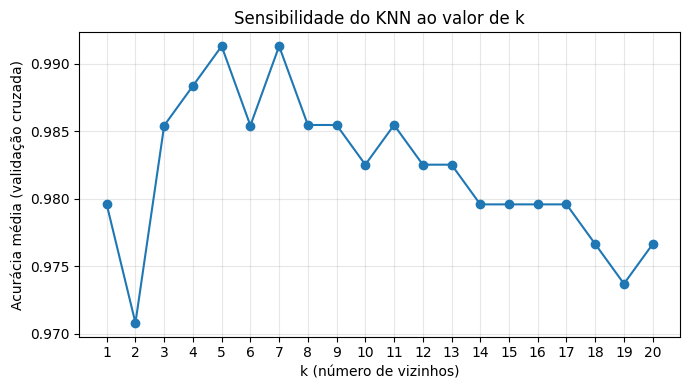

Melhor k: 5 -> acurácia média = 0.991


In [ ]:
ks = range(1, 21)          # testa k de 1 até 20
medias = []

for k in ks:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    s = cross_val_score(pipe_k, X, y, cv=cv, scoring='accuracy')
    medias.append(s.mean())

# Gráfico: acurácia média (CV) para cada valor de k
plt.plot(list(ks), medias, marker='o')
plt.xlabel("k (número de vizinhos)")
plt.ylabel("Acurácia média (validação cruzada)")
plt.title("Sensibilidade do KNN ao valor de k")
plt.xticks(list(ks))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

melhor_k = list(ks)[int(np.argmax(medias))]
print("Melhor k:", melhor_k, "-> acurácia média = %.3f" % max(medias))

### Interpretação da validação cruzada

A validação cruzada confirma a robustez do modelo:

- **Estabilidade entre partições:** com 5 folds, a acurácia média foi de **99,1%**, com desvio-padrão de apenas **0,012**. As notas individuais variaram de ~97,1% a 100%. Ou seja, o desempenho alto **não** foi um acaso da divisão única treino/teste que usamos antes — ele se sustenta em diferentes recortes dos dados.

- **Robustez ao hiperparâmetro `k`:** ao varrer `k` de 1 a 20, a acurácia se manteve numa faixa estreita ~0,971 a 0,991, sem nenhum colapso. O melhor valor foi **k = 5** ~0,991. Note que `k = 2` foi o pior ponto — valores **pares** de `k` podem gerar empates na votação dos vizinhos, o que costuma piorar levemente o resultado; por isso, na prática, prefere-se `k` **ímpar**. A região mais estável e de melhor desempenho está entre `k = 3` e `k = 11`.

**Conclusão da seção:** o classificador KNN, aplicado sobre os dados **padronizados**, é confiável para este problema — tanto entre diferentes partições quanto numa ampla faixa de `k`. Isso reforça a mensagem central do trabalho: com o pré-processamento correto (padronização) e uma validação honesta (cross-validation), chegamos a um modelo simples, porém sólido.